In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from src.utils import save_figure

# Setting Visual Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.autolayout': True, 'axes.titlesize': 16, 'axes.labelsize': 12})
print("✅ Environment setup complete.")

✅ Environment setup complete.


In [3]:
print("Loading pristine datasets... (This may take a few seconds)")

df_enrol = pd.read_csv('../data/processed/cleaned_aadhar_enrolment_merged.csv', parse_dates=['date'])
df_bio = pd.read_csv('../data/processed/cleaned_aadhar_biometric_merged.csv', parse_dates=['date'])
df_demo = pd.read_csv('../data/processed/cleaned_aadhar_demographic_merged.csv', parse_dates=['date'])

print("✅ Data loaded successfully!")
print(f"Enrolment: {len(df_enrol):,} rows | Biometric: {len(df_bio):,} rows | Demographic: {len(df_demo):,} rows")

Loading pristine datasets... (This may take a few seconds)
✅ Data loaded successfully!
Enrolment: 1,006,007 rows | Biometric: 1,861,108 rows | Demographic: 2,071,687 rows


C:\Users\Asus\AppData\Local\Temp\ipykernel_12440\2760617833.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=state_infants.values, y=state_infants.index, palette="viridis")


Saved figure to c:\Users\Asus\Documents\UIDAI Data Hackathon 2026\reports\figures\01_top_infant_enrolments_20260407_022147.png


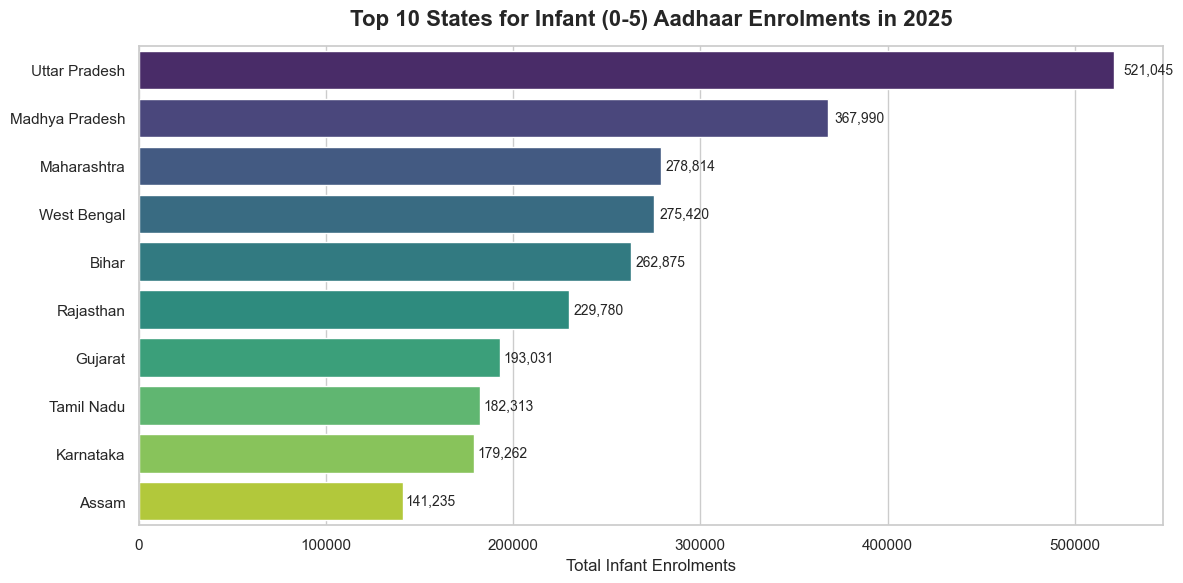

In [4]:
plt.figure(figsize=(12, 6))

# Group by state, sum the 0-5 age group, and get the top 10
state_infants = df_enrol.groupby('state')['age_0_5'].sum().nlargest(10)

# Create a polished bar chart
ax = sns.barplot(x=state_infants.values, y=state_infants.index, palette="viridis")
plt.title('Top 10 States for Infant (0-5) Aadhaar Enrolments in 2025', pad=15, fontweight='bold')
plt.xlabel('Total Infant Enrolments')
plt.ylabel('') # Leave blank for cleaner look

# Add data labels to the bars for readability
for i, v in enumerate(state_infants.values):
    ax.text(v + (v * 0.01), i, f'{v:,.0f}', va='center', fontsize=10)

save_figure(plt.gcf(), '01_top_infant_enrolments')
plt.show()

Saved figure to c:\Users\Asus\Documents\UIDAI Data Hackathon 2026\reports\figures\02_monthly_update_trends_20260407_022210.png


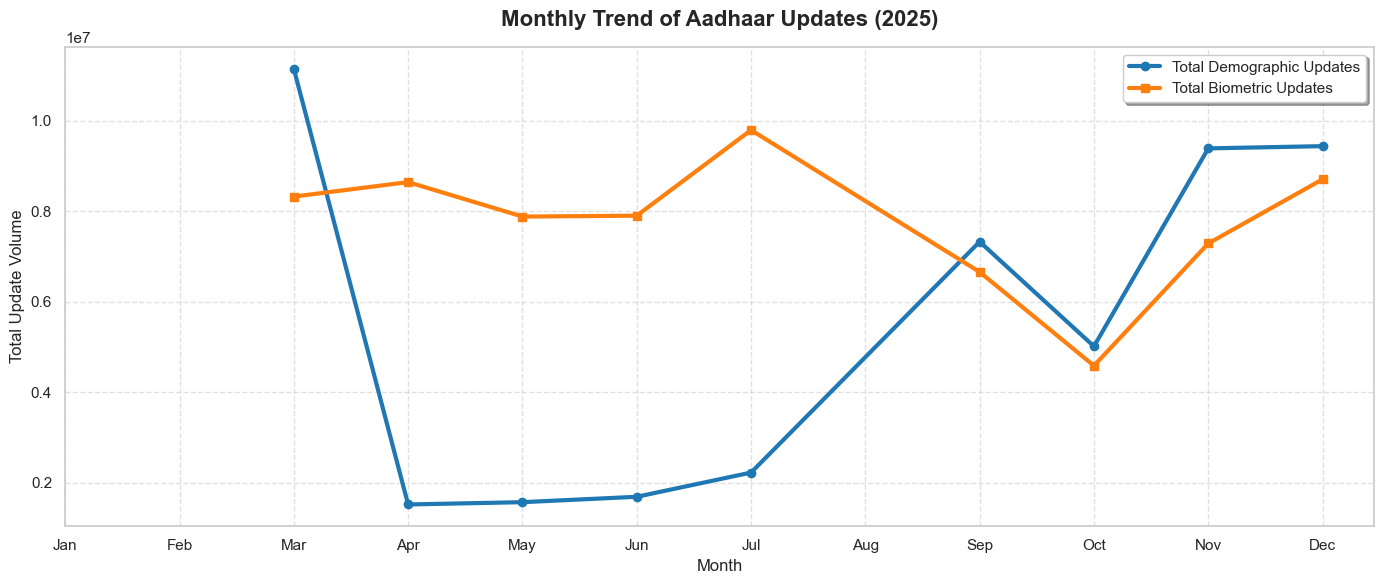

In [5]:
plt.figure(figsize=(14, 6))

# Extract month for trend analysis
df_demo['month'] = df_demo['date'].dt.month
df_bio['month'] = df_bio['date'].dt.month

# Group by month (summing both age brackets together for total volume)
monthly_demo = df_demo.groupby('month')[['demo_age_5_17', 'demo_age_17_']].sum().sum(axis=1)
monthly_bio = df_bio.groupby('month')[['bio_age_5_17', 'bio_age_17_']].sum().sum(axis=1)

# Plot both lines to compare volume
plt.plot(monthly_demo.index, monthly_demo.values, marker='o', linewidth=3, label='Total Demographic Updates', color='#1f77b4')
plt.plot(monthly_bio.index, monthly_bio.values, marker='s', linewidth=3, label='Total Biometric Updates', color='#ff7f0e')

plt.title('Monthly Trend of Aadhaar Updates (2025)', pad=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Update Volume')
plt.xticks(range(1, 13), [calendar.month_abbr[i] for i in range(1, 13)]) # Show Jan, Feb, Mar
plt.legend(frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)

save_figure(plt.gcf(), '02_monthly_update_trends')
plt.show()

Saved figure to c:\Users\Asus\Documents\UIDAI Data Hackathon 2026\reports\figures\03_workload_distribution_20260407_022223.png


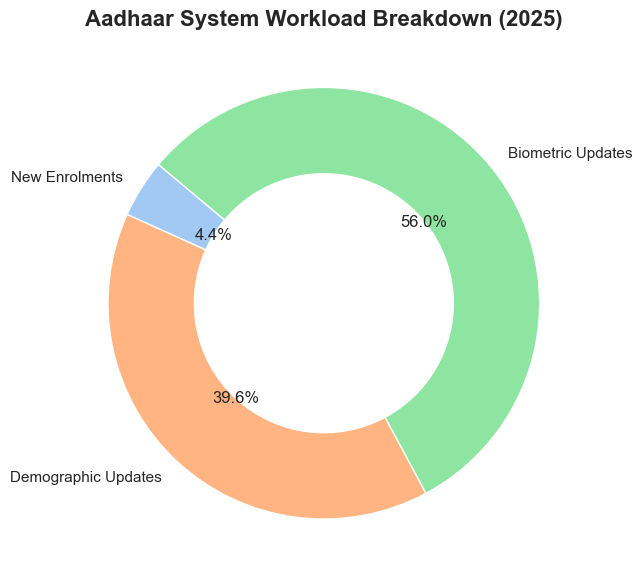

In [6]:
plt.figure(figsize=(8, 6))

# Calculate total volume per dataset
totals = {
    'New Enrolments': df_enrol[['age_0_5', 'age_5_17', 'age_18_greater']].sum().sum(),
    'Demographic Updates': df_demo[['demo_age_5_17', 'demo_age_17_']].sum().sum(),
    'Biometric Updates': df_bio[['bio_age_5_17', 'bio_age_17_']].sum().sum()
}

# Create a donut chart
plt.pie(totals.values(), labels=totals.keys(), autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette("pastel"), wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title('Aadhaar System Workload Breakdown (2025)', fontweight='bold')

save_figure(plt.gcf(), '03_workload_distribution')
plt.show()

Saved figure to c:\Users\Asus\Documents\UIDAI Data Hackathon 2026\reports\figures\04_hardware_bottleneck_scatter_20260407_022435.png


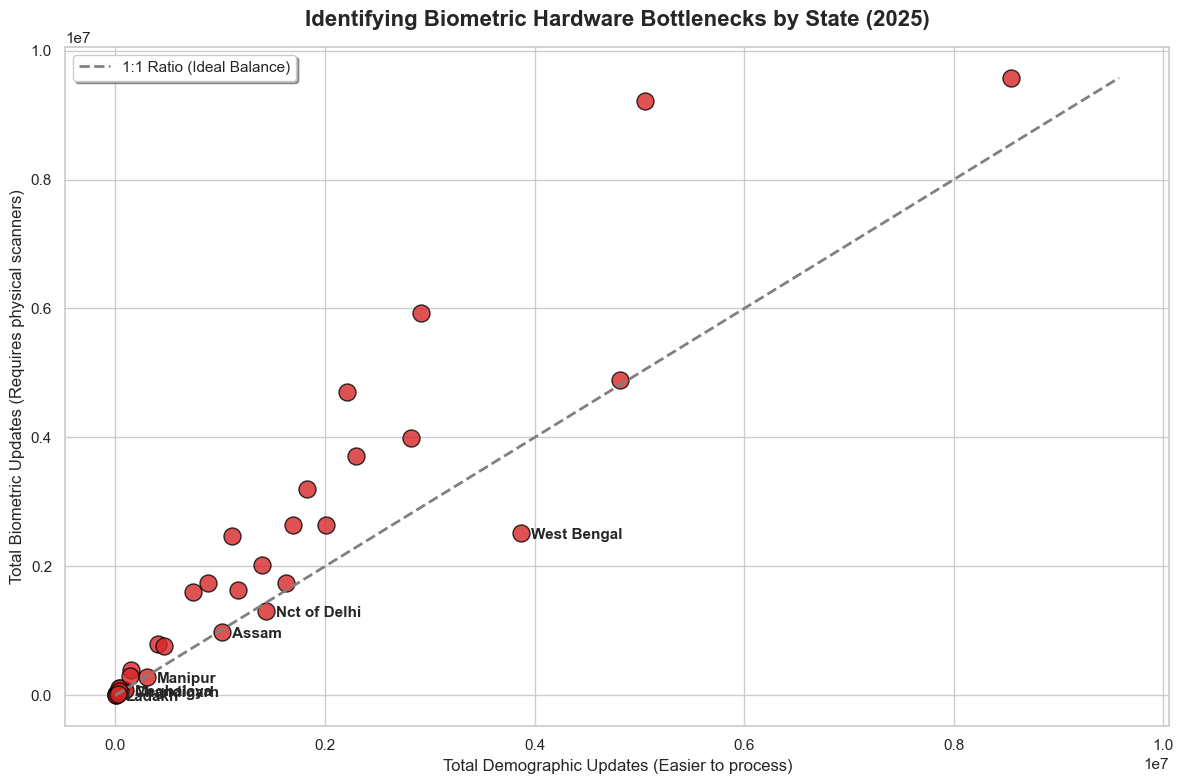

In [7]:
# INSIGHT 4: The Hardware Bottleneck (State Level)
plt.figure(figsize=(12, 8))

# Aggregate total updates by state for both datasets
state_demo = df_demo.groupby('state')[['demo_age_5_17', 'demo_age_17_']].sum().sum(axis=1)
state_bio = df_bio.groupby('state')[['bio_age_5_17', 'bio_age_17_']].sum().sum(axis=1)

# Combine into a single dataframe
df_hardware = pd.DataFrame({'Demographic': state_demo, 'Biometric': state_bio}).fillna(0)

# Create a scatter plot
ax = sns.scatterplot(data=df_hardware, x='Demographic', y='Biometric', s=150, color='#d62728', alpha=0.8, edgecolor='black')

# Add a diagonal line (1:1 ratio)
# States far BELOW this line have high demographic updates but terrible biometric coverage
max_val = max(df_hardware.max())
plt.plot([0, max_val], [0, max_val], '--', color='grey', linewidth=2, label='1:1 Ratio (Ideal Balance)')

# Automatically annotate the top 7 states with the largest "bottleneck" (biggest gap)
df_hardware['Gap'] = df_hardware['Demographic'] - df_hardware['Biometric']
top_bottlenecks = df_hardware.nlargest(7, 'Gap')

for state, row in top_bottlenecks.iterrows():
    ax.text(row['Demographic'] + (max_val*0.01), row['Biometric'] - (max_val*0.01), 
            state, fontsize=11, fontweight='bold')

plt.title('Identifying Biometric Hardware Bottlenecks by State (2025)', pad=15, fontweight='bold', fontsize=16)
plt.xlabel('Total Demographic Updates (Easier to process)', fontsize=12)
plt.ylabel('Total Biometric Updates (Requires physical scanners)', fontsize=12)
plt.legend(frameon=True, shadow=True)

save_figure(plt.gcf(), '04_hardware_bottleneck_scatter')
plt.show()

insights in findings.md